# Module 04 — Cell Type Annotation Overview

This notebook summarises the per-dataset cell type annotation produced by
`scripts/04_annotation.py`. Each of the **12 datasets** (436,558 cells total)
was independently annotated using two complementary strategies:

1. **Marker-based scoring** — expanded IVD-specific gene signatures (16 signatures
   covering 4 NP subtypes, 3 AF subtypes, 2 EP subtypes, and 6 non-resident types)
   scored with `sc.tl.score_genes()`, followed by cluster-level majority voting at
   Leiden resolution 0.8.
2. **CellTypist** — the `Immune_All_Low` model refines immune and endothelial
   subtype labels. Reference-based label transfer was not applied because no
   IVD-specific reference atlas is publicly available.

A consensus framework merges the results: CellTypist labels are preferred for
non-resident populations (immune, endothelial, pericyte), while marker-based
labels are used for resident IVD cells (NP, AF, EP subtypes). Cells where
neither strategy produced a confident call are labelled "unassigned."

**Manuscript mapping:** Figure 1 — IVD cell atlas overview (UMAP, dot plot,
proportions). Supplementary Figure S2 — per-dataset annotation details and
strategy comparison.

**Data sources:**
- `data/processed/{accession}.h5ad` — annotated AnnData objects (12 files, with `cell_type_final` in `.obs`)
- `results/annotations/{accession}_markers.tsv` — top 50 Wilcoxon markers per cluster (from Module 03)

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='scanpy')

from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
PROC_DIR = BASE / 'data' / 'processed'
ANN_DIR = BASE / 'results' / 'annotations'
ANN_DIR.mkdir(parents=True, exist_ok=True)

ALL_ACCESSIONS = [
    'GSE160756', 'GSE165722', 'GSE189916', 'GSE199866', 'GSE205535',
    'CNP0002664', 'GSE233666', 'GSE244889', 'GSE251686', 'GSE255768',
    'GSE230809', 'GSE242443',
]

PALETTE = dict(zip(ALL_ACCESSIONS, sns.color_palette('tab20', len(ALL_ACCESSIONS))))

# ── Load obs DataFrames (no .X) ──────────────────────────────────────────
obs_frames = {}
for acc in ALL_ACCESSIONS:
    path = PROC_DIR / f'{acc}.h5ad'
    if not path.exists():
        print(f'  SKIP {acc}: file not found')
        continue
    adata = sc.read_h5ad(path, backed='r')
    obs_frames[acc] = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    adata.file.close()
    print(f'  {acc}: {len(obs_frames[acc]):,} cells')

print(f'\nLoaded {len(obs_frames)} datasets')

  GSE160756: 89,283 cells


  GSE165722: 37,978 cells


  GSE189916: 19,658 cells


  GSE199866: 13,896 cells


  GSE205535: 10,121 cells


...

  GSE244889: 51,519 cells


  GSE251686: 36,415 cells


  GSE255768: 8,886 cells


  GSE230809: 105,804 cells


  GSE242443: 14,938 cells

Loaded 12 datasets


## Summary Table

The table below shows the final cell type counts per dataset after consensus
labelling. Each dataset was annotated independently — the cell types reflect
expanded IVD-specific signatures (NP subtypes, AF subtypes, endplate) plus
CellTypist-refined immune and stromal populations.

In [2]:
# Collect cell type counts per dataset
ct_records = []
for acc in ALL_ACCESSIONS:
    if acc not in obs_frames:
        continue
    obs = obs_frames[acc]
    if 'cell_type_final' not in obs.columns:
        continue
    counts = obs['cell_type_final'].value_counts()
    for ct, n in counts.items():
        ct_records.append({'accession': acc, 'cell_type': ct, 'count': n})

ct_df = pd.DataFrame(ct_records)

# Pivot table: datasets × cell types
pivot = ct_df.pivot_table(index='accession', columns='cell_type', values='count',
                          fill_value=0, aggfunc='sum')
pivot = pivot.loc[[a for a in ALL_ACCESSIONS if a in pivot.index]]

# Add totals
pivot['TOTAL'] = pivot.sum(axis=1)

display(pivot.style.set_caption('Cell Type Counts per Dataset (Final Consensus Labels)'))

cell_type,AF_inner,AF_mechanical_stress,AF_outer,Alveolar macrophages,B_cell,CD16+ NK cells,Classical monocytes,DC,EP_hyaline_cartilage,EP_ossification,Endothelial cells,Fibroblasts,Intermediate macrophages,Macrophages,Mast cells,Memory B cells,NK cells,NP_fibrocartilaginous,NP_mature_chondrocyte,NP_notochordal,NP_stressed_degenerative,Naive B cells,Neutrophil-myeloid progenitor,Pericyte_SMC,Plasma cells,Pro-B cells,Small pre-B cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,TOTAL
accession,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GSE160756,0,1746,19249,0,0,0,0,0,0,0,3886,1539,0,0,0,0,403,0,62460,0,0,0,0,0,0,0,0,0,0,0,0,89283
GSE165722,1457,0,14860,0,0,594,1,202,0,0,68,0,0,328,146,158,0,0,0,6491,11928,0,0,0,90,0,54,730,0,284,587,37978
GSE189916,4647,2059,11480,0,0,0,0,0,0,0,136,198,0,0,0,0,0,1039,0,0,98,0,0,1,0,0,0,0,0,0,0,19658
GSE199866,0,0,13874,0,0,0,0,0,0,0,0,0,0,22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13896
GSE205535,4899,0,4509,1,0,0,63,0,0,0,37,1,0,61,0,0,0,49,463,0,0,0,0,0,0,0,0,38,0,0,0,10121
CNP0002664,5986,0,15678,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7760,0,185,0,0,0,0,0,0,0,0,0,0,29609
GSE233666,0,4034,12081,241,0,0,0,0,0,0,223,0,77,0,19,0,0,0,0,0,1657,0,0,0,0,0,0,0,0,0,119,18451
GSE244889,11764,7171,5871,0,90,0,0,0,0,107,1383,124,0,0,17,0,318,0,16585,2769,3164,347,2,0,302,129,192,0,593,0,591,51519
GSE251686,2462,0,8627,0,0,0,0,0,0,0,840,0,0,1414,0,0,0,0,23072,0,0,0,0,0,0,0,0,0,0,0,0,36415


## UMAP Grid — Cell Types per Dataset

Each row shows one dataset. The UMAP is computed per-dataset (before integration)
and colored by the final consensus cell type label. This gives a visual overview of
the cell populations present in each study and whether the annotation captures
biologically meaningful clusters.

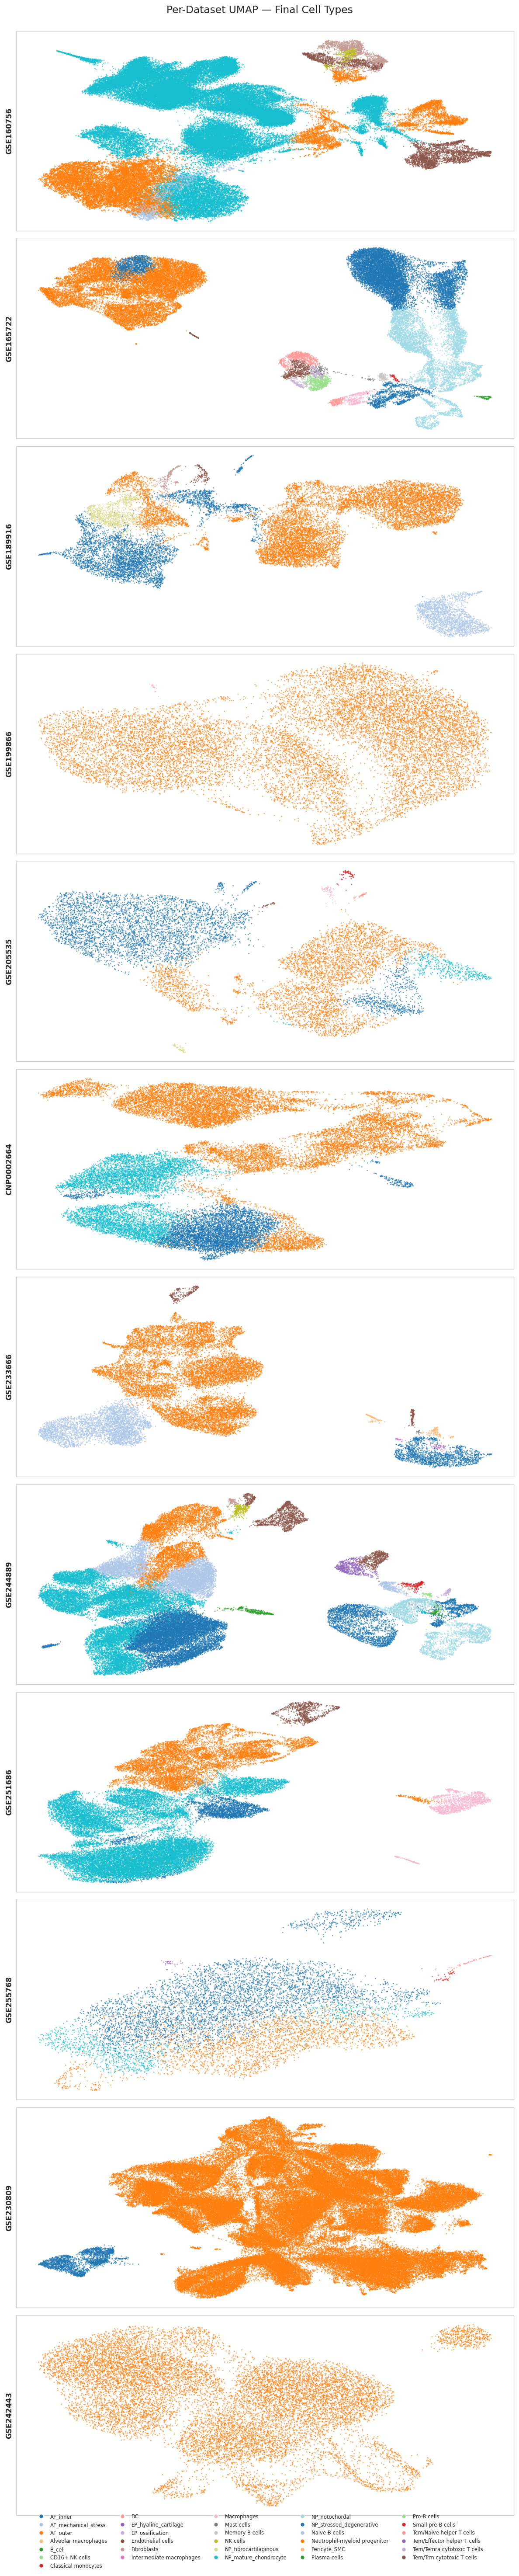

In [3]:
# Collect all unique cell types across datasets for a shared palette
all_types = set()
for acc in ALL_ACCESSIONS:
    if acc in obs_frames and 'cell_type_final' in obs_frames[acc].columns:
        all_types |= set(obs_frames[acc]['cell_type_final'].unique())
all_types = sorted(all_types)
n_types = len(all_types)
type_palette = dict(zip(all_types, sns.color_palette('tab20', max(n_types, 20))[:n_types]))

# Load UMAP embeddings
umap_data = {}
for acc in ALL_ACCESSIONS:
    path = PROC_DIR / f'{acc}.h5ad'
    if not path.exists() or acc not in obs_frames:
        continue
    if 'cell_type_final' not in obs_frames[acc].columns:
        continue
    adata = sc.read_h5ad(path, backed='r')
    umap_data[acc] = adata.obsm['X_umap'][:]
    adata.file.close()

datasets = [a for a in ALL_ACCESSIONS if a in umap_data]
n_datasets = len(datasets)

fig, axes = plt.subplots(n_datasets, 1, figsize=(10, 4 * n_datasets))
if n_datasets == 1:
    axes = [axes]

for ax, acc in zip(axes, datasets):
    umap = umap_data[acc]
    labels = obs_frames[acc]['cell_type_final'].values
    idx = np.random.RandomState(42).permutation(len(umap))
    colors = [type_palette.get(labels[i], '#cccccc') for i in idx]
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=0.5, alpha=0.6, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_ylabel(acc, fontsize=10, fontweight='bold')

# Legend at the bottom
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=type_palette[t],
                   markersize=6, label=t) for t in all_types]
fig.legend(handles=handles, loc='lower center', ncol=min(5, n_types),
           fontsize=7, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Per-Dataset UMAP — Final Cell Types', fontsize=14, y=1.0)
fig.tight_layout()
fig.savefig(ANN_DIR / 'notebook_04_umap_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## Dot Plot — Canonical Markers × Cell Types

Aggregated across all datasets: for each final cell type label, we show the
expression of key marker genes. This validates that annotations are biologically
coherent — e.g., NP_notochordal cells should express KRT19/KRT8, endothelial
cells should express PECAM1/VWF, etc.

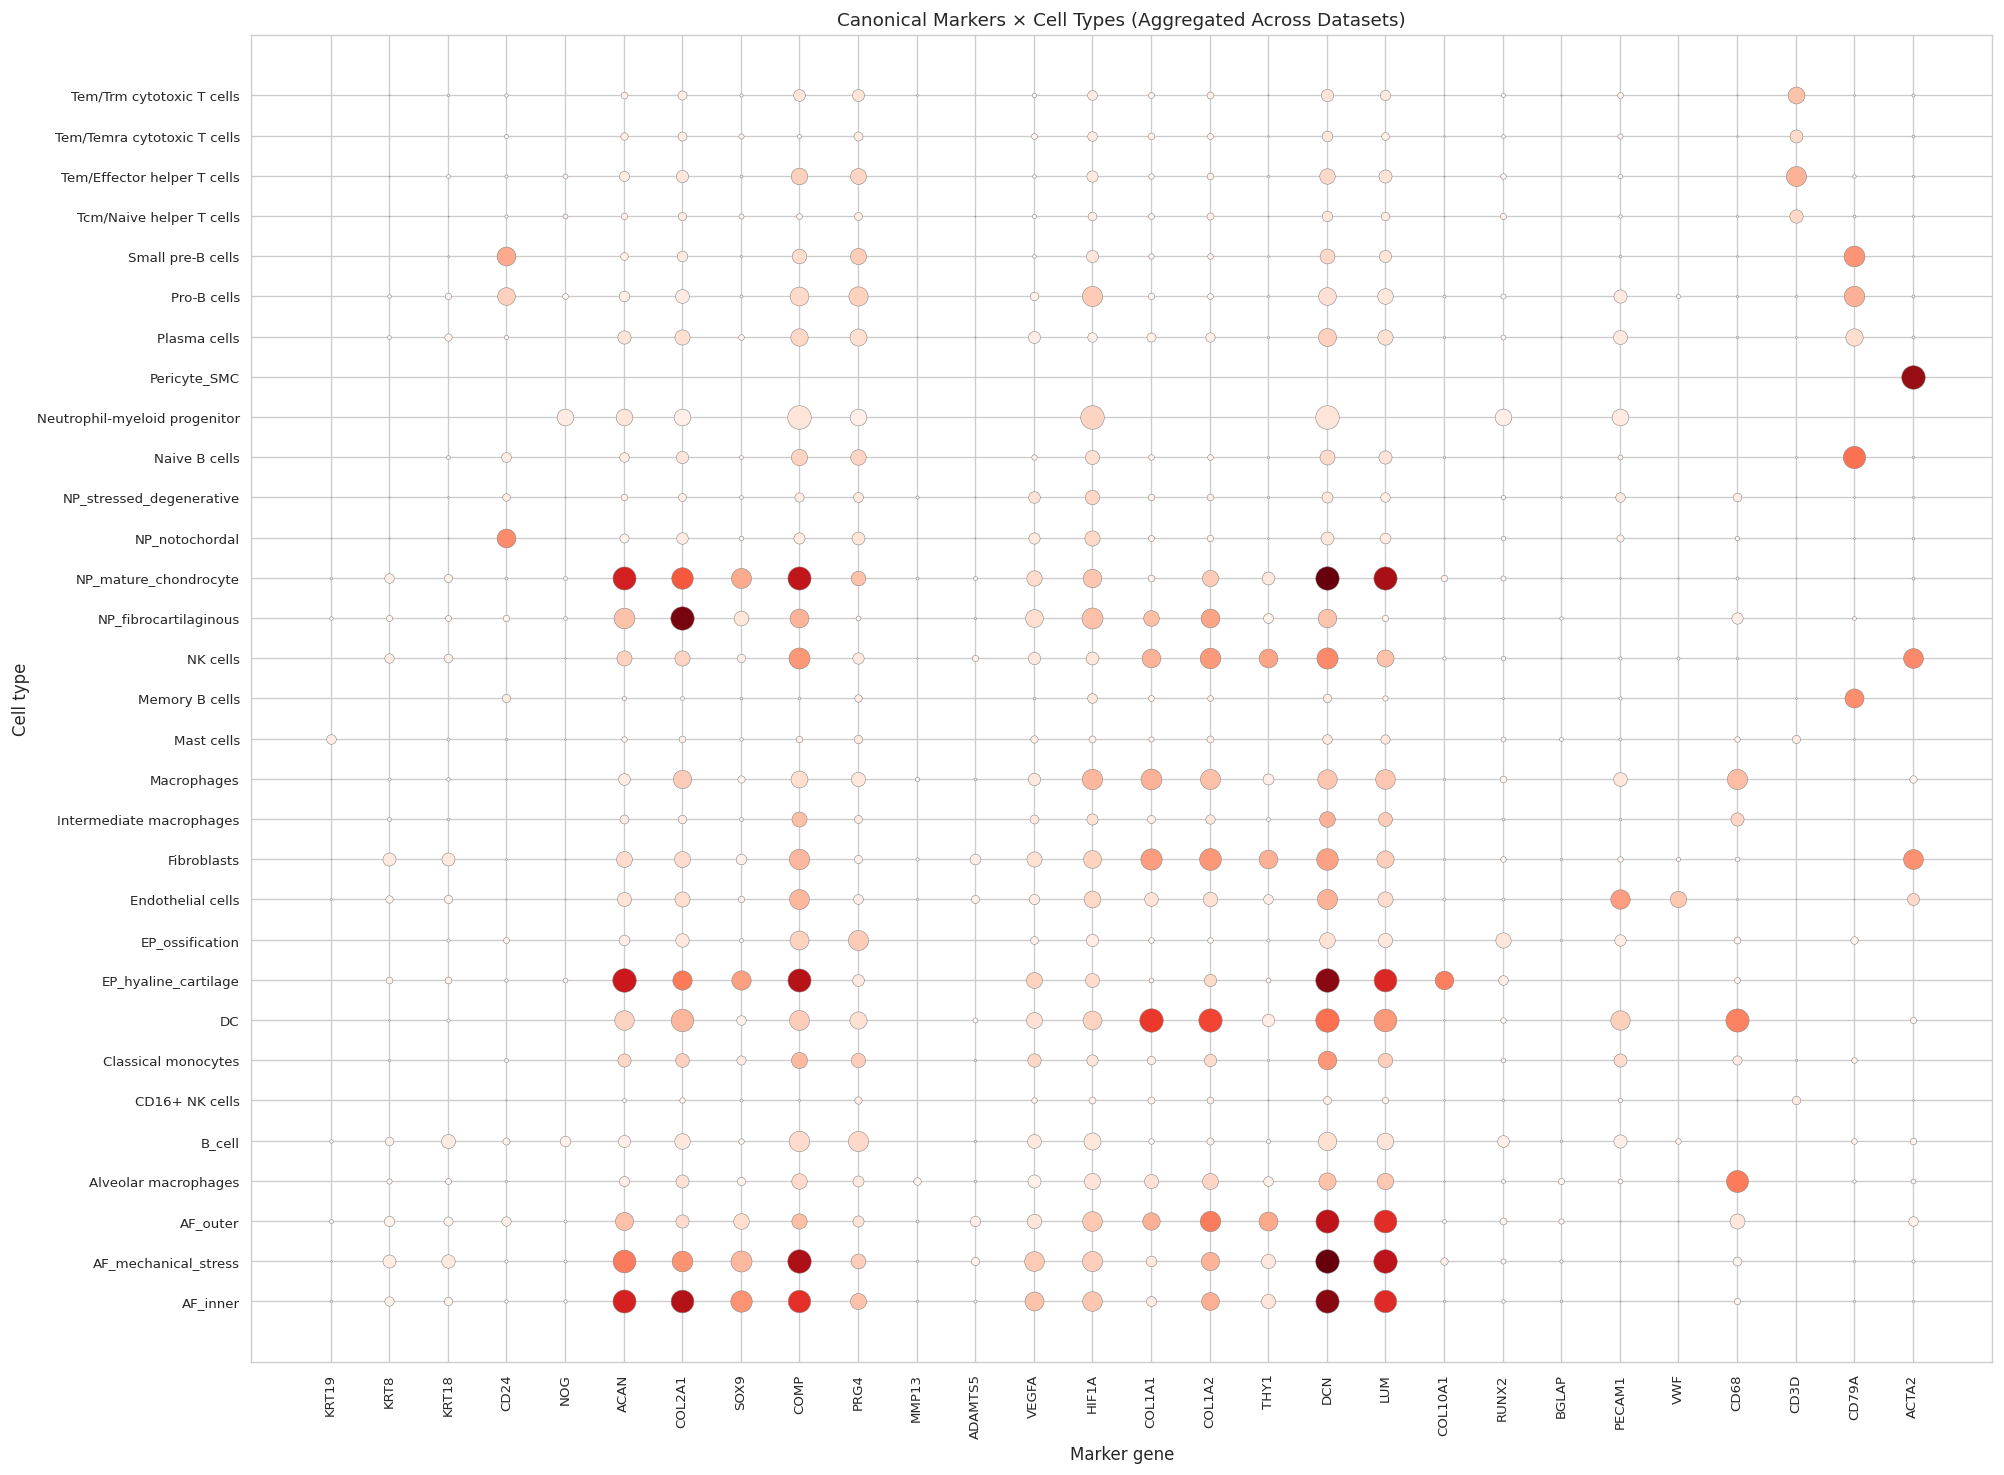

In [4]:
# For the dotplot we need expression data — load one dataset at a time and
# compute mean expression per cell type, then pool.
MARKER_GENES = [
    # NP
    'KRT19', 'KRT8', 'KRT18', 'CD24', 'NOG',
    # NP mature
    'ACAN', 'COL2A1', 'SOX9', 'COMP', 'PRG4',
    # NP degenerative
    'MMP13', 'ADAMTS5', 'VEGFA', 'HIF1A',
    # AF
    'COL1A1', 'COL1A2', 'THY1', 'DCN', 'LUM',
    # EP
    'COL10A1', 'RUNX2', 'BGLAP',
    # Immune/stromal
    'PECAM1', 'VWF', 'CD68', 'CD3D', 'CD79A', 'ACTA2',
]

# Pool mean expression across datasets
mean_records = []
frac_records = []
for acc in ALL_ACCESSIONS:
    path = PROC_DIR / f'{acc}.h5ad'
    if acc not in obs_frames or 'cell_type_final' not in obs_frames[acc].columns:
        continue
    adata = sc.read_h5ad(path)
    available = [g for g in MARKER_GENES if g in adata.var_names]
    if not available:
        del adata; continue
    sub = adata[:, available]
    from scipy import sparse
    X = sub.X.toarray() if sparse.issparse(sub.X) else np.asarray(sub.X)
    ct_labels = obs_frames[acc]['cell_type_final'].values
    for ct in np.unique(ct_labels):
        mask = ct_labels == ct
        expr = X[mask]
        mean_expr = expr.mean(axis=0)
        frac_expr = (expr > 0).mean(axis=0)
        for j, gene in enumerate(available):
            mean_records.append({'cell_type': ct, 'gene': gene,
                                 'mean_expr': mean_expr[j], 'n_cells': mask.sum()})
            frac_records.append({'cell_type': ct, 'gene': gene,
                                 'frac_expr': frac_expr[j], 'n_cells': mask.sum()})
    del adata, sub, X

# Weighted average across datasets
mean_df = pd.DataFrame(mean_records)
frac_df = pd.DataFrame(frac_records)
if len(mean_df) > 0:
    mean_agg = mean_df.groupby(['cell_type', 'gene']).apply(
        lambda g: np.average(g['mean_expr'], weights=g['n_cells'])
    ).reset_index(name='mean_expr')
    frac_agg = frac_df.groupby(['cell_type', 'gene']).apply(
        lambda g: np.average(g['frac_expr'], weights=g['n_cells'])
    ).reset_index(name='frac_expr')

    # Pivot for heatmap
    mean_pivot = mean_agg.pivot(index='cell_type', columns='gene', values='mean_expr').fillna(0)
    frac_pivot = frac_agg.pivot(index='cell_type', columns='gene', values='frac_expr').fillna(0)

    # Reorder genes
    gene_order = [g for g in MARKER_GENES if g in mean_pivot.columns]
    mean_pivot = mean_pivot[gene_order]
    frac_pivot = frac_pivot[gene_order]

    # Custom dot plot
    fig, ax = plt.subplots(figsize=(max(14, len(gene_order) * 0.6),
                                    max(6, len(mean_pivot) * 0.4)))
    cell_types_sorted = mean_pivot.index.tolist()
    for i, ct in enumerate(cell_types_sorted):
        for j, gene in enumerate(gene_order):
            size = frac_pivot.loc[ct, gene] * 200
            color_val = mean_pivot.loc[ct, gene]
            ax.scatter(j, i, s=size, c=color_val, cmap='Reds', vmin=0,
                       vmax=mean_pivot.values.max(), edgecolors='grey', linewidth=0.3)

    ax.set_xticks(range(len(gene_order)))
    ax.set_xticklabels(gene_order, rotation=90, fontsize=8)
    ax.set_yticks(range(len(cell_types_sorted)))
    ax.set_yticklabels(cell_types_sorted, fontsize=8)
    ax.set_title('Canonical Markers × Cell Types (Aggregated Across Datasets)', fontsize=11)
    ax.set_xlabel('Marker gene')
    ax.set_ylabel('Cell type')

    fig.tight_layout()
    fig.savefig(ANN_DIR / 'notebook_04_dotplot.png', dpi=150)
    plt.show()
else:
    print('No expression data available for dotplot')

## Stacked Bar — Cell Type Proportions per Dataset

The stacked bar chart shows the relative proportions of each cell type within
each dataset. This highlights compositional differences that may reflect tissue
compartment (NP vs AF vs mixed), disease state, or technical differences in cell
capture.

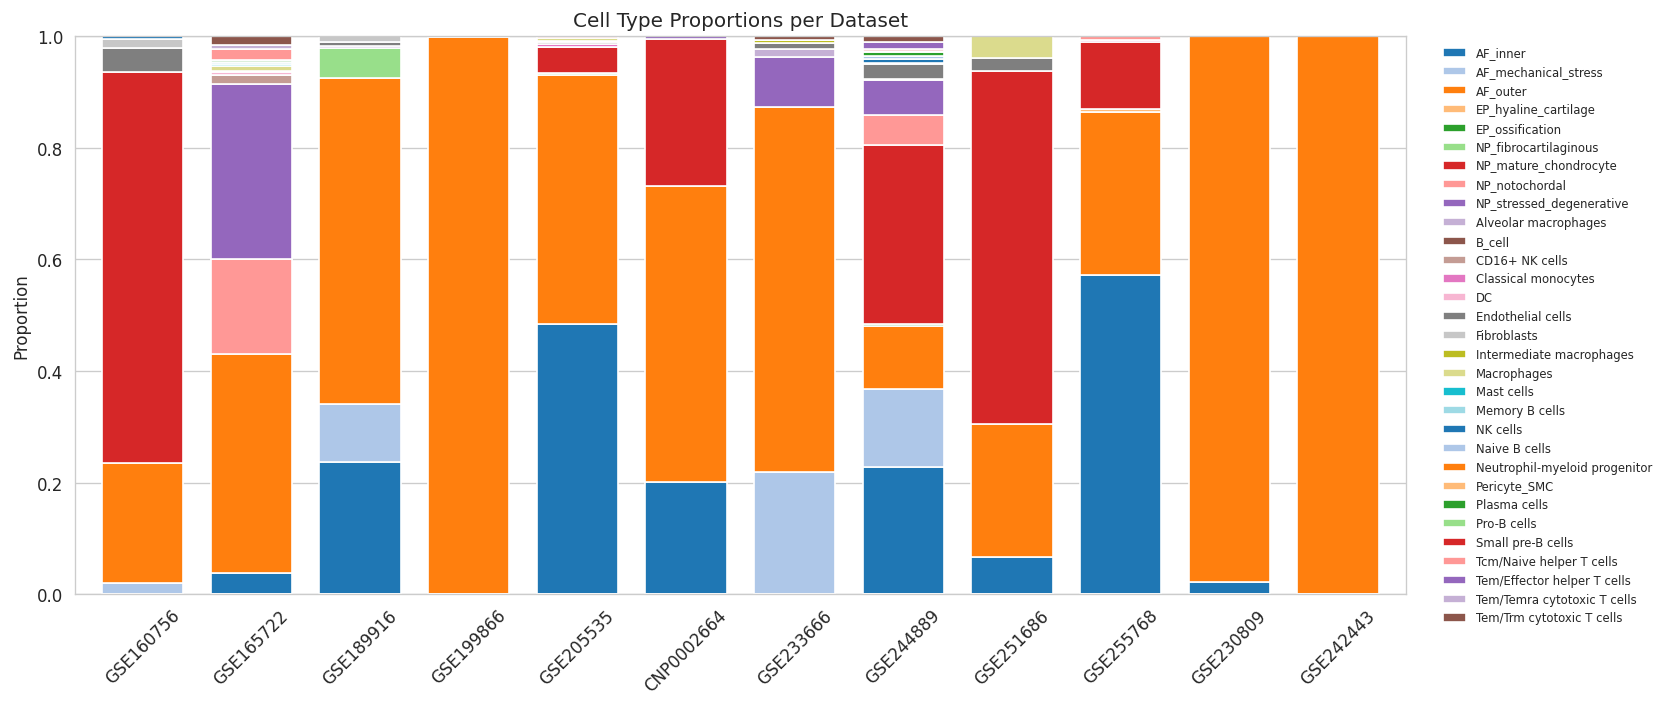

In [5]:
# Build proportion matrix
prop_records = []
for acc in ALL_ACCESSIONS:
    if acc not in obs_frames or 'cell_type_final' not in obs_frames[acc].columns:
        continue
    obs = obs_frames[acc]
    n = len(obs)
    counts = obs['cell_type_final'].value_counts()
    for ct, cnt in counts.items():
        prop_records.append({'accession': acc, 'cell_type': ct, 'proportion': cnt / n})

prop_df = pd.DataFrame(prop_records)
prop_pivot = prop_df.pivot_table(index='accession', columns='cell_type',
                                  values='proportion', fill_value=0)
prop_pivot = prop_pivot.loc[[a for a in ALL_ACCESSIONS if a in prop_pivot.index]]

# Sort columns: resident first (NP, AF, EP), then non-resident, then unassigned
resident_cols = sorted([c for c in prop_pivot.columns
                         if c.startswith(('NP_', 'AF_', 'EP_'))])
non_resident_cols = sorted([c for c in prop_pivot.columns
                             if c not in resident_cols and c != 'unassigned'])
unassigned = ['unassigned'] if 'unassigned' in prop_pivot.columns else []
col_order = resident_cols + non_resident_cols + unassigned
prop_pivot = prop_pivot[[c for c in col_order if c in prop_pivot.columns]]

# Colours
n_cols = len(prop_pivot.columns)
bar_colors = sns.color_palette('tab20', max(n_cols, 20))[:n_cols]

fig, ax = plt.subplots(figsize=(14, 6))
prop_pivot.plot.bar(stacked=True, ax=ax, color=bar_colors, width=0.75, edgecolor='white')
ax.set_ylabel('Proportion')
ax.set_xlabel('')
ax.set_title('Cell Type Proportions per Dataset')
ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, frameon=False)
ax.set_ylim(0, 1)

fig.tight_layout()
fig.savefig(ANN_DIR / 'notebook_04_proportions.png', dpi=150, bbox_inches='tight')
plt.show()

## Strategy Agreement Heatmap

For cells where both marker-based and CellTypist labels were available, this
heatmap shows the co-occurrence matrix. Perfect agreement would be a diagonal
pattern. Off-diagonal entries reveal where the strategies disagree — this is
expected for resident IVD cells, where CellTypist (trained on immune data)
is not informative, and less expected for immune populations.

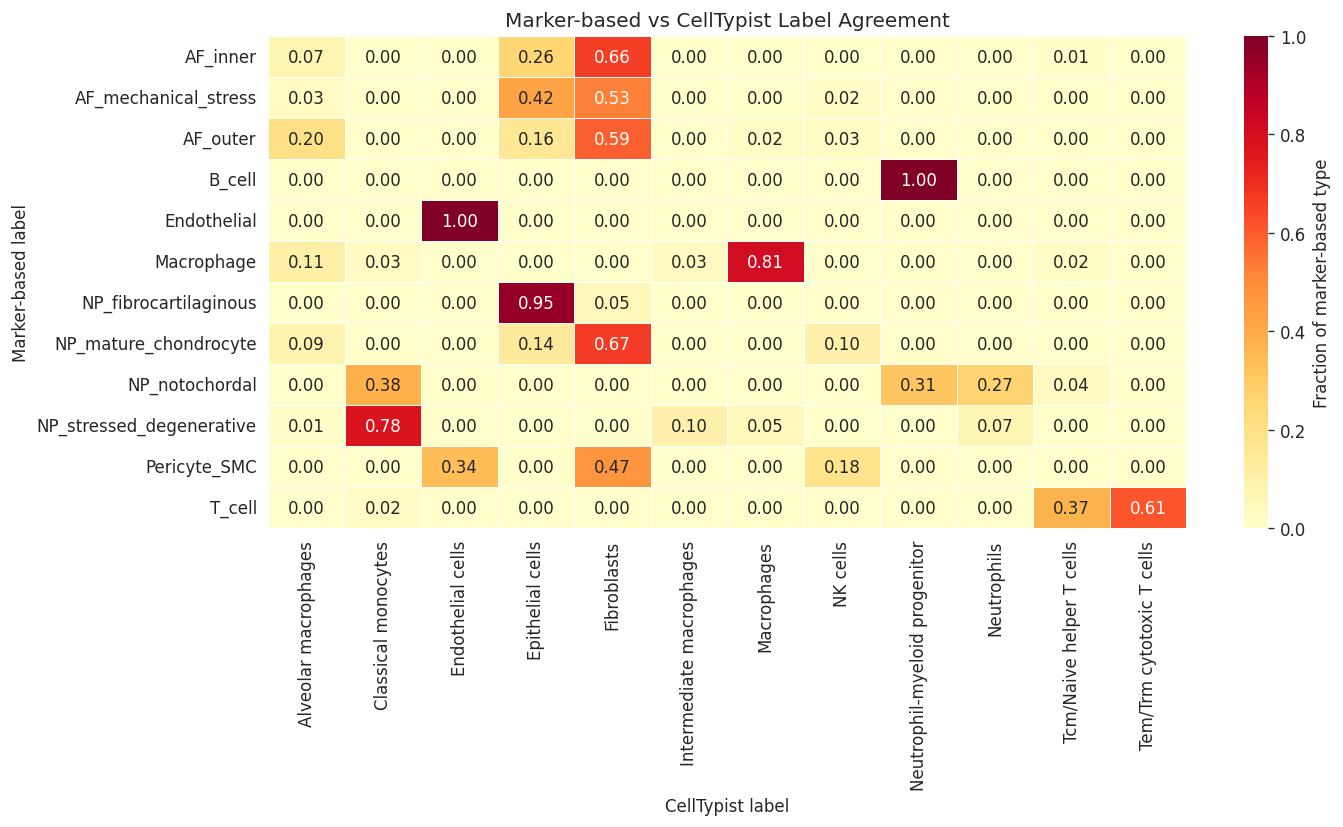

In [6]:
# Pool marker-based vs CellTypist labels across all datasets
agreement_records = []
for acc in ALL_ACCESSIONS:
    if acc not in obs_frames:
        continue
    obs = obs_frames[acc]
    if 'cell_type_marker_based' not in obs.columns or 'cell_type_celltypist' not in obs.columns:
        continue
    # Skip datasets where CellTypist didn't run
    if obs['cell_type_celltypist'].iloc[0] in ('not_available', 'model_unavailable', 'failed'):
        continue
    sub = obs[['cell_type_marker_based', 'cell_type_celltypist']].copy()
    agreement_records.append(sub)

if agreement_records:
    agree_df = pd.concat(agreement_records, ignore_index=True)
    # Build co-occurrence matrix (top N labels for readability)
    top_marker = agree_df['cell_type_marker_based'].value_counts().head(12).index
    top_ct = agree_df['cell_type_celltypist'].value_counts().head(12).index
    sub = agree_df[
        agree_df['cell_type_marker_based'].isin(top_marker) &
        agree_df['cell_type_celltypist'].isin(top_ct)
    ]
    confusion = pd.crosstab(sub['cell_type_marker_based'], sub['cell_type_celltypist'],
                            normalize='index')

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(confusion, cmap='YlOrRd', annot=True, fmt='.2f', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Fraction of marker-based type'})
    ax.set_xlabel('CellTypist label')
    ax.set_ylabel('Marker-based label')
    ax.set_title('Marker-based vs CellTypist Label Agreement')

    fig.tight_layout()
    fig.savefig(ANN_DIR / 'notebook_04_agreement_heatmap.png', dpi=150)
    plt.show()
else:
    print('CellTypist labels not available — skipping agreement heatmap')

## NP Subtype Score Distributions

The IVD resident cell populations — particularly NP cells — exist on a
continuum rather than in discrete clusters. The four continuous signature
scores (notochordal, mature chondrocyte, stressed/degenerative,
fibrocartilaginous) capture this biology. The density plots below show
these scores across datasets, split by disease condition, revealing which
NP cell programs are enriched in healthy vs degenerated tissue.

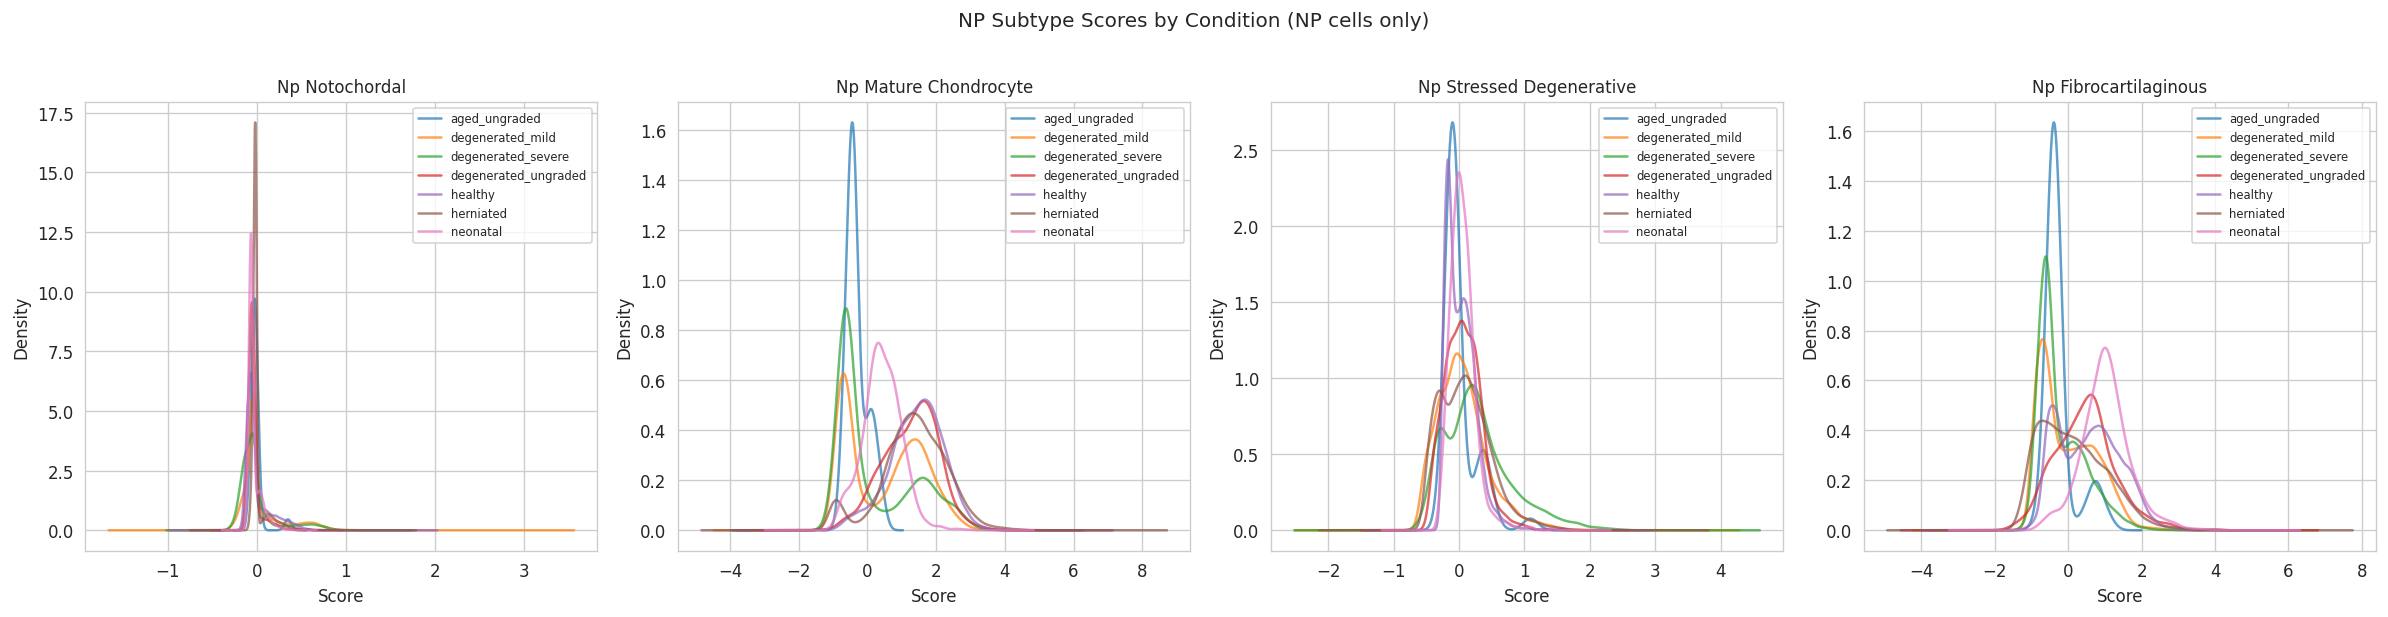

In [7]:
# Collect NP subtype scores
np_score_cols = ['score_NP_notochordal', 'score_NP_mature_chondrocyte',
                 'score_NP_stressed_degenerative', 'score_NP_fibrocartilaginous']

score_records = []
for acc in ALL_ACCESSIONS:
    if acc not in obs_frames:
        continue
    obs = obs_frames[acc]
    available = [c for c in np_score_cols if c in obs.columns]
    if not available:
        continue
    sub = obs[available + ['cell_type_final']].copy()
    if 'condition_harmonized' in obs.columns:
        sub['condition'] = obs['condition_harmonized']
    else:
        sub['condition'] = 'unknown'
    sub['accession'] = acc
    # Keep only NP-labeled cells
    np_mask = sub['cell_type_final'].str.startswith('NP_', na=False)
    if np_mask.sum() > 0:
        score_records.append(sub[np_mask])

if score_records:
    scores_df = pd.concat(score_records, ignore_index=True)
    available_score_cols = [c for c in np_score_cols if c in scores_df.columns]

    fig, axes = plt.subplots(1, len(available_score_cols),
                              figsize=(5 * len(available_score_cols), 5))
    if len(available_score_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, available_score_cols):
        for cond in sorted(scores_df['condition'].unique()):
            data = scores_df.loc[scores_df['condition'] == cond, col].dropna()
            if len(data) > 10:
                data.plot.kde(ax=ax, label=cond, alpha=0.7)
        ax.set_title(col.replace('score_', '').replace('_', ' ').title(), fontsize=10)
        ax.set_xlabel('Score')
        ax.legend(fontsize=7)

    fig.suptitle('NP Subtype Scores by Condition (NP cells only)', fontsize=12, y=1.02)
    fig.tight_layout()
    fig.savefig(ANN_DIR / 'notebook_04_np_scores_by_condition.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No NP subtype scores available')

## Label Transition — Preliminary to Final

This heatmap shows how cells flow from the preliminary coarse labels
(Module 03: 10 broad types based on 3-4 markers each) to the refined final labels
(Module 04: expanded signatures + CellTypist consensus). Large off-diagonal values
indicate that the expanded signatures and CellTypist successfully resolved
ambiguity in the preliminary annotation. For example, cells initially labelled
"Chondrocyte_NP" are split into NP_notochordal, NP_mature_chondrocyte, etc.

Note: this maps Module 03 preliminary labels to Module 04 final labels, not
original author-provided annotations (which vary widely in nomenclature and
are not stored in a standardized field).

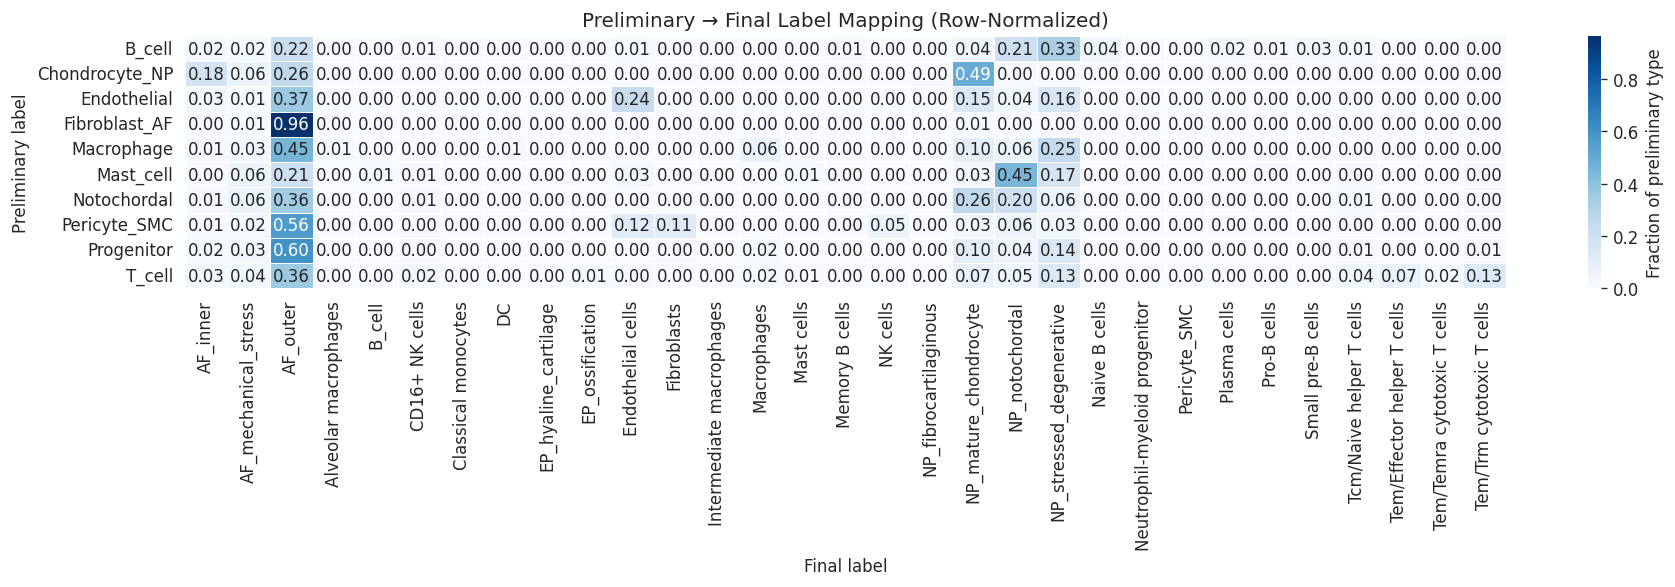

In [8]:
# Collect preliminary → final mappings
flow_records = []
for acc in ALL_ACCESSIONS:
    if acc not in obs_frames:
        continue
    obs = obs_frames[acc]
    if 'cell_type_preliminary' not in obs.columns or 'cell_type_final' not in obs.columns:
        continue
    for (prel, final), n in obs.groupby(['cell_type_preliminary', 'cell_type_final']).size().items():
        flow_records.append({'preliminary': prel, 'final': final, 'count': n})

if flow_records:
    flow_df = pd.DataFrame(flow_records)
    flow_agg = flow_df.groupby(['preliminary', 'final'])['count'].sum().reset_index()
    flow_agg = flow_agg.sort_values('count', ascending=False)

    # Simple grouped bar representation of the mapping (Sankey requires plotly)
    # Show top transitions as a heatmap
    transition = flow_agg.pivot_table(index='preliminary', columns='final',
                                       values='count', fill_value=0)
    # Normalize by row
    transition_norm = transition.div(transition.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(max(12, len(transition_norm.columns) * 0.5),
                                    max(5, len(transition_norm) * 0.5)))
    sns.heatmap(transition_norm, cmap='Blues', annot=True, fmt='.2f', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Fraction of preliminary type'})
    ax.set_xlabel('Final label')
    ax.set_ylabel('Preliminary label')
    ax.set_title('Preliminary → Final Label Mapping (Row-Normalized)')

    fig.tight_layout()
    fig.savefig(ANN_DIR / 'notebook_04_label_transition.png', dpi=150)
    plt.show()
else:
    print('Preliminary labels not available for comparison')

## Notes and Next Steps

**Annotation parameters:**
- Expanded gene signatures: 16 signatures (4 NP, 3 AF, 2 EP, 6 non-resident)
- Clustering resolution for label assignment: 0.8
- CellTypist model: `Immune_All_Low.pkl` with majority voting
- Strategy 2 (reference-based): not applied — no IVD-specific atlas available

**Consensus rules:**
- Non-resident cells: CellTypist preferred when it returns a specific immune subtype
- Resident IVD cells: marker-based labels only
- Ambiguous cells: labelled "unassigned" with confidence "low"

**Figures saved** to `results/annotations/` with the `notebook_04_` prefix for
inclusion in the manuscript.

In [9]:
saved_figures = sorted(ANN_DIR.glob('notebook_04_*.png'))
print('Saved figures:')
for f in saved_figures:
    print(f'  {f.relative_to(BASE)}')

Saved figures:
  results/annotations/notebook_04_agreement_heatmap.png
  results/annotations/notebook_04_dotplot.png
  results/annotations/notebook_04_label_transition.png
  results/annotations/notebook_04_np_scores_by_condition.png
  results/annotations/notebook_04_proportions.png
  results/annotations/notebook_04_umap_grid.png
